# Create Synthetic Time Series

<a id='Import_modules'></a> 
## Import Libraries

In [2]:
# Import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

<a id='Read_price_data'></a>
## Read price data

In [3]:
# Read the price data
bars5m = pd.read_pickle('MLT-07_data_PriceData.pick')

# Display the last 5 entries of price data
bars5m.tail()

,open,high,low,close,volume
Time,,,,,
2014-08-18 19:35:00,99.294,99.304,99.280,99.296,2637.2
2014-08-18 19:40:00,99.300,99.308,99.286,99.298,1997.6
2014-08-18 19:45:00,99.302,99.312,99.292,99.310,1546.0
2014-08-18 19:50:00,99.308,99.320,99.296,99.318,1620.8
2014-08-18 19:55:00,99.316,99.322,99.302,99.320,2751.2


<a id='Create_synthetic_ohlc'></a>
## Create synthetic OHLCV

Synthetic OHLCV is the simulated price of an underlying, based on the underlying's price data, but offset by a random noisy signal. You need to define a function `create_synth_ohlc()` for doing this.

The term OHLCV stands for Open, High, Low, Close and Volume of the underlying asset.

The logical flow for creating synthetic OHLCV is as :
1. The base signal, `y` is taken. In this notebook, you will work with the base signal as sine, trending and mixed types
1. Some standard normal noise multiplied by some factor `mult` is added to the signal
1. The `open` and `close` prices are made using the above signal + noise from the step above
1. The `high` and `low` prices are made so that they are almost 1 unit away from the `open` and `close`
1. The `volume` is arbitrarily set to 1000
1. All these values are then fed into a DataFrame and returned for further use

In [4]:
def create_synth_ohlc(y,df,mult=1): 
    """
    This creates a data frame with synthetic open/high/low/close prices
    based on the dates of the original price data for test and
    comparison.

    A wave y is taken which has some particular nature(sine wave/trending/etc).
    A DataFrame df is taken which gives us the length of the synthetic data to 
    be constructed.
    A multiplier mult is taken, with a default value of 1.
    """
    
    # Generate synthetic data using the randn()

    # wave + multiplier * random number is done for the length of df
    op = pd.Series(y+mult*np.random.randn(len(df)),index=df.index)
    cl = pd.Series(y+mult*np.random.randn(len(df)),index=df.index)

    # Assuming high and low to be 1 unit further away
    # High : wave + 1 + multiplier * random number is done for the length of df
    hi = pd.Series(y+1+mult*np.abs(np.random.randn(len(df))),index=df.index)

    # Low : wave - 1 - multiplier * random number is done for the length of df
    lo = pd.Series(y-1-mult*np.abs(np.random.randn(len(df))),index=df.index)
    vol = pd.Series(1000,index=df.index)
    
    # Make a DataFrame from the synthetic data
    # .T is to transpose the DataFrame
    dfs = pd.DataFrame([op,hi,lo,cl,vol]).T
    
    # Price date is stored in data_modules
    dfs.index.rename('Time',inplace=True)
    
    # Rename columns
    dfs.columns = ['open','high','low','close','volume']
    return dfs

<a id='Mean_reverting_time_series'></a>
## Mean reverting time series

To create a mean-reverting time series, you need to perform the following steps:
1. A sine wave pattern `y` is created using the `sin()` in the `numpy` package
1. The sine wave `y` is passed to the `create_synth_ohlc` function where some noise is added and a synthetic time series data frame is returned

**Note:** For this notebook, we use the first 5000 data points since this is just an illustrative example.

In [5]:
def create_synth_sine_time_series(df, mult):
    """
    This creates an artificial prices series for trends and/or sine waves
    and optionally, noise can be added to this.
    """
    
    # Create an array of increasing independent numbers(x)
    x = np.arange(len(df))

    # Create an array of dependent values(y) by computing the equation
    y = 10*np.sin(0.005*x)+100

    # Pass the sine wave pattern to create a synthetic time series based on it
    sine_ts = create_synth_ohlc(y, df, mult)

    return sine_ts


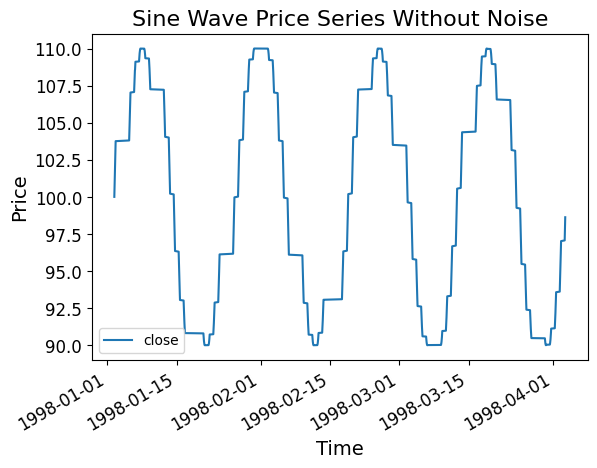

In [10]:
# Create a sine wave pattern(without noise) for the time series for the first 5000 data points
sine_ts = create_synth_sine_time_series(bars5m.iloc[:5000], mult = 0)

# Define the figure size for the sine wave plot
sine_ts[:]['close'].plot()

# Add legend to the axis
plt.legend()

# Add labels
plt.ylabel('Price', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.title('Sine Wave Price Series Without Noise', fontsize=16)
    
# Define the tick size for x-axis and y-axis
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the plot
plt.show()

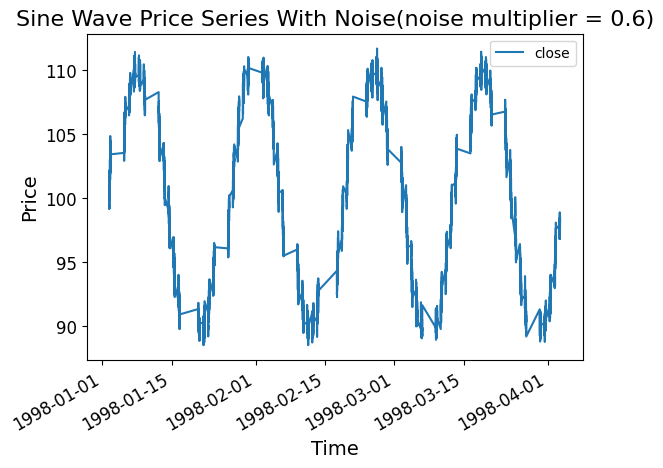

In [9]:
# Create a sine wave pattern(with noise) for the time series for the first 5000 data points
sine_ts = create_synth_sine_time_series(bars5m.iloc[:5000], mult = 0.6)

# Define the figure size for the sine wave plot
sine_ts[:]['close'].plot()

# Add legend to the axis
plt.legend()

# Add labels
plt.ylabel('Price', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.title('Sine Wave Price Series With Noise(noise multiplier = 0.6)', fontsize=16)
    
# Define the tick size for x-axis and y-axis
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the plot
plt.show()